In [8]:
import numpy as np
traj300K = np.load('results/results_CASIMODO_DHFR_300K/discretizing_npy/discretized_array.npy')
traj339K = np.load('results/results_CASIMODO_DHFR_339K/discretizing_npy/discretized_array.npy')

print(traj300K.shape)
print(traj339K.shape)

(50001, 365)
(50001, 724)


# Finding a common set of LVs at different temperatures

So we can see that the subset of LVs found by CASIMODO at the two different temperatures is not the same. Since the task we are interested in consists in comparing the two simulation sets at some point, we should work on a set of LVs that is the intersection of these two.

In [10]:
path_300K = 'results/results_CASIMODO_DHFR_300K/discretized_local_variables.txt'
path_339K = 'results/results_CASIMODO_DHFR_339K/discretized_local_variables.txt'

# Read only the first column (the variable names) as strings
LVs_300K= np.loadtxt(path_300K, usecols=0, dtype=str)
LVs_339K= np.loadtxt(path_339K, usecols=0, dtype=str)

common = np.intersect1d(LVs_300K, LVs_339K)

common, idx_300K, idx_339K = np.intersect1d(LVs_300K, LVs_339K, return_indices=True)

data_300K_common = traj300K[:, idx_300K]   # shape: (len(common), n_frames_300K)
data_339K_common = traj339K[:, idx_339K]   # shape: (len(common), n_frames_339K)

print(data_339K_common.shape)
#np.save('Analysis300K_339K/disc_array_commonset_300K.npy',data_300K_common)
#np.save('Analysis300K_339K/disc_array_commonset_339K.npy',data_339K_common)

(50001, 303)


# Computing correlations
We need to compute the correlations between LVs using directly the continuous trajectories.

In [23]:
import os
import numpy as np

temperatures = ['300K', '339K']

# Restrict to the LVs found at both temperatures (`common`, computed above)
LV_names = list(common)

corr = {}
cov = {}
for T in temperatures:
    LV_dir = f'results/results_CASIMODO_DHFR_{T}/local_variables_data'
    # Each .dat file has two columns: time and LV value; keep only the values
    LV_traj = np.array([np.loadtxt(os.path.join(LV_dir, name + '.dat'), usecols=1) for name in LV_names])   # shape: (n_LVs, n_frames)

    # Pearson correlation and covariance between every pair of LVs
    corr[T] = np.corrcoef(LV_traj)   # shape: (n_LVs, n_LVs)
    cov[T] = np.cov(LV_traj)         # shape: (n_LVs, n_LVs)
    print(T, LV_traj.shape, corr[T].shape)

corr_300K, corr_339K = corr['300K'], corr['339K']
cov_300K, cov_339K = cov['300K'], cov['339K']

300K (303, 50001) (303, 303)
339K (303, 50001) (303, 303)


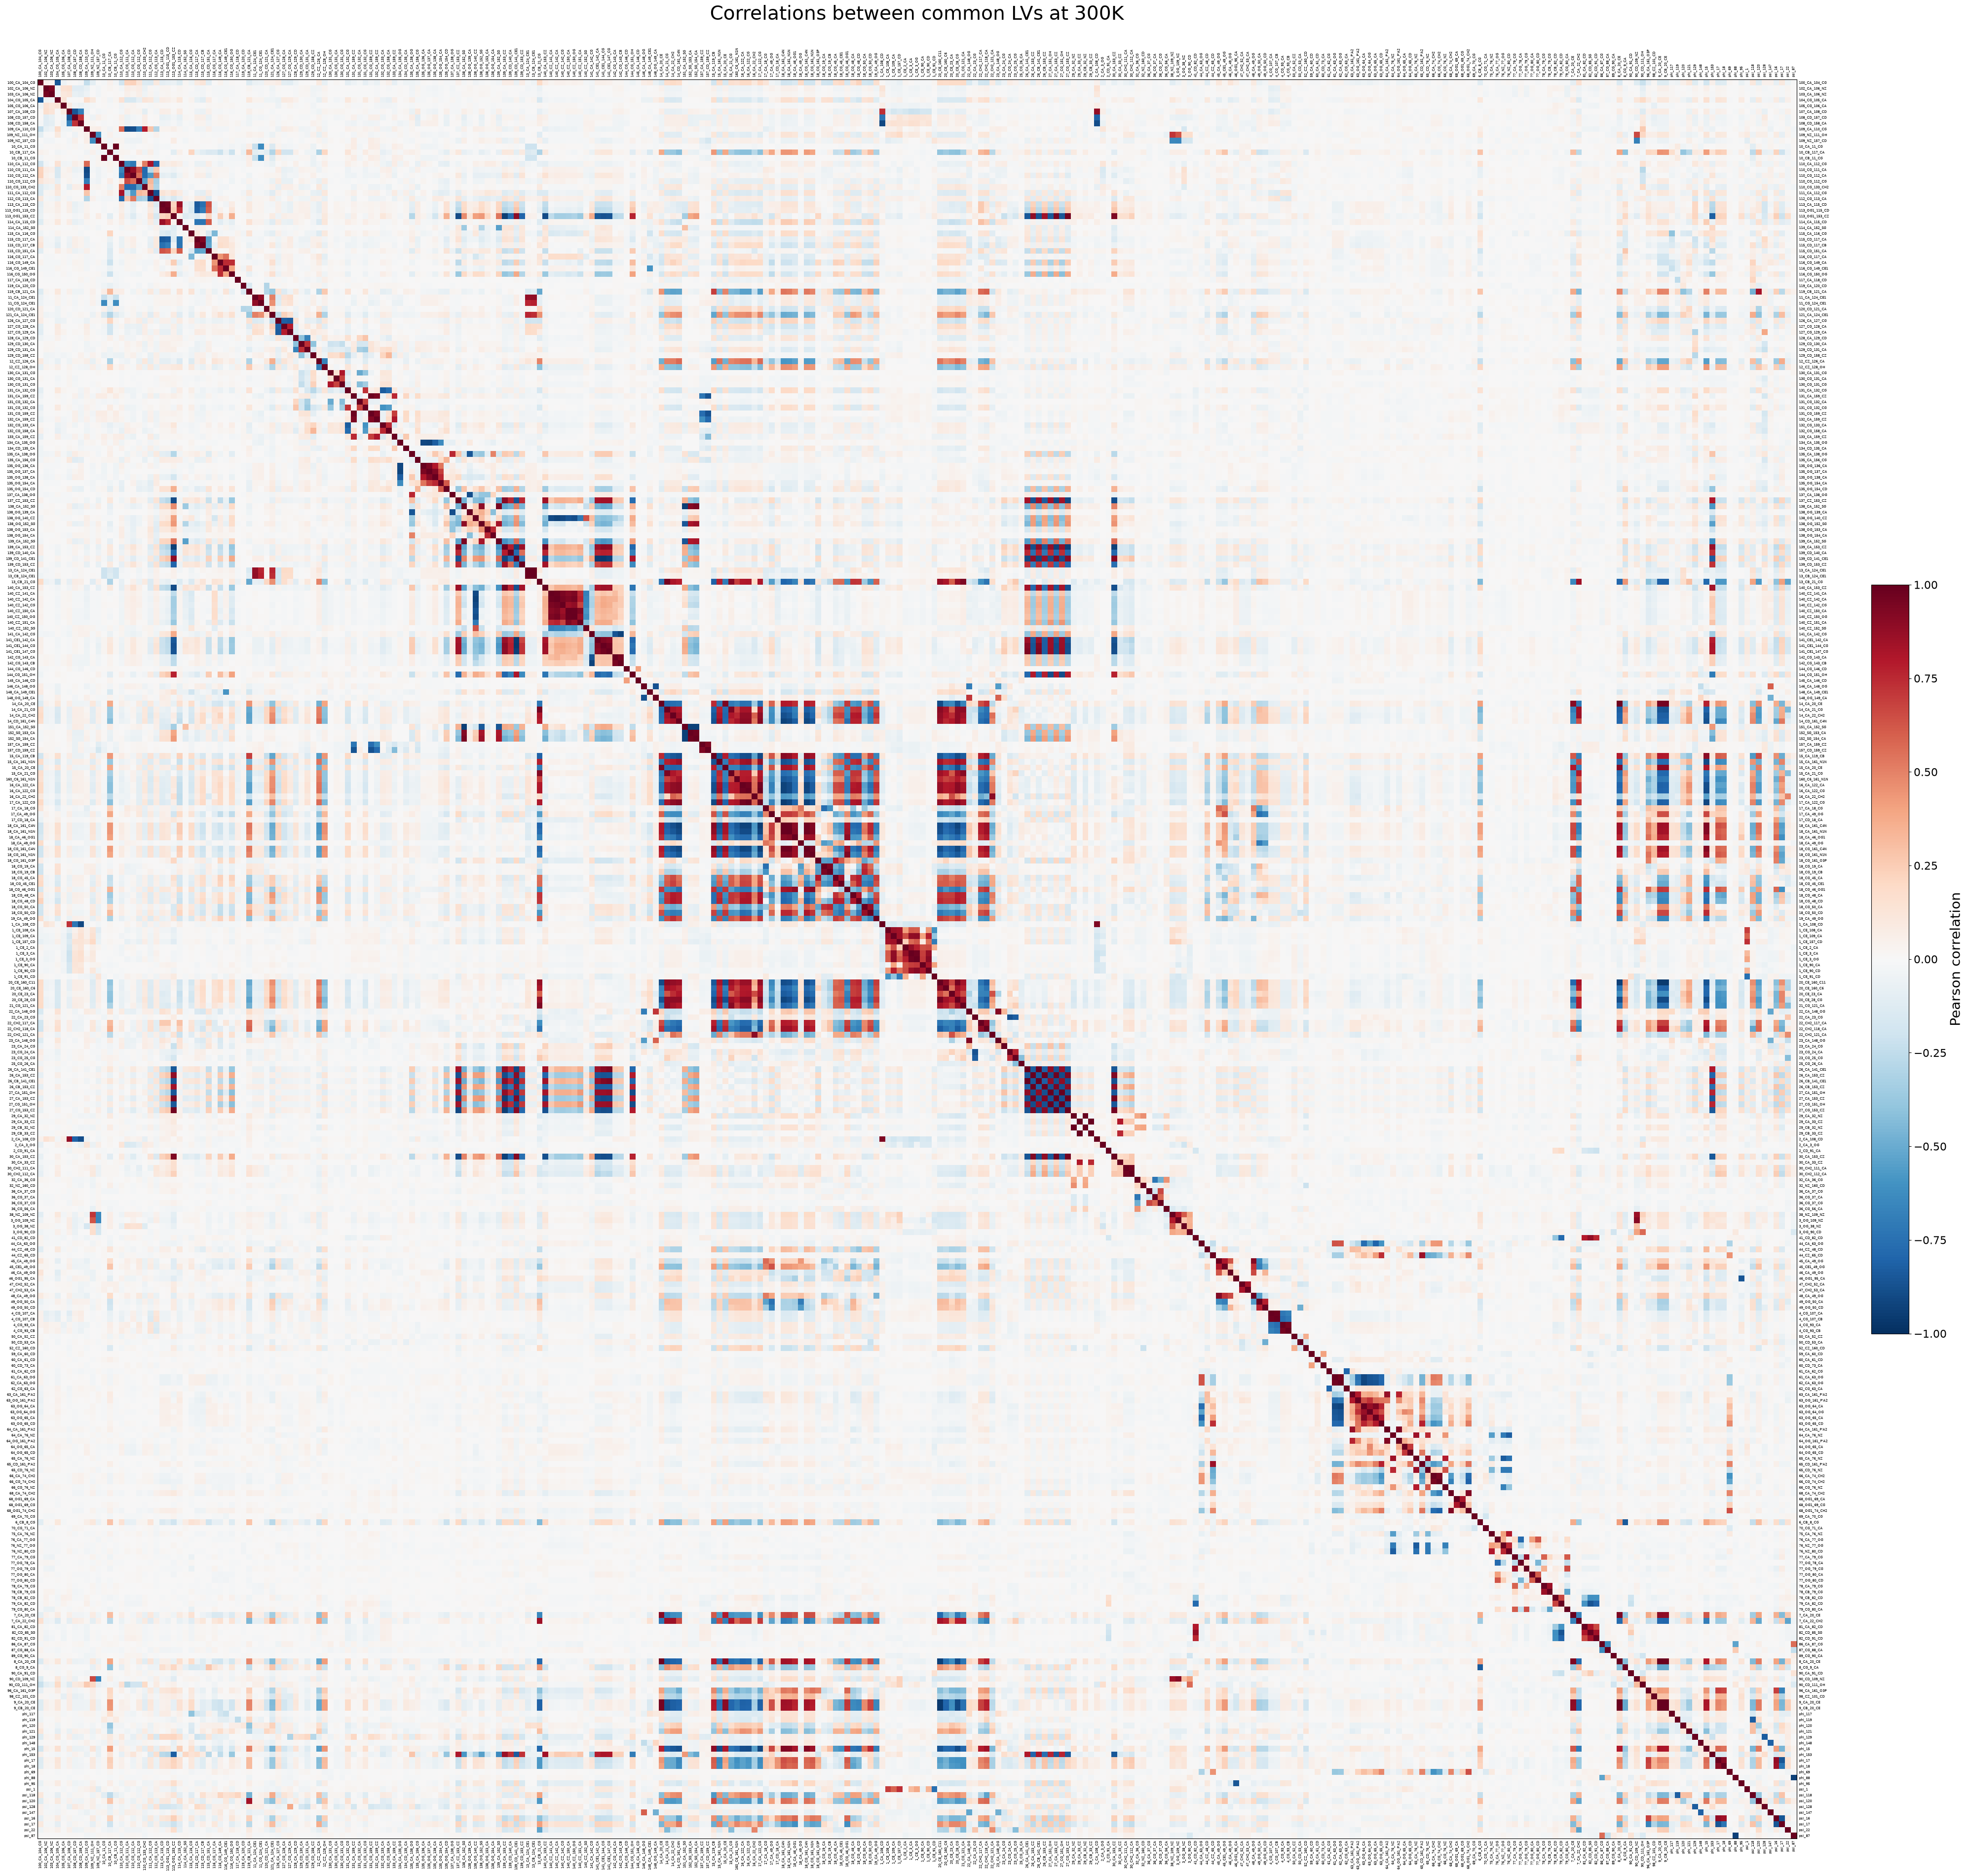

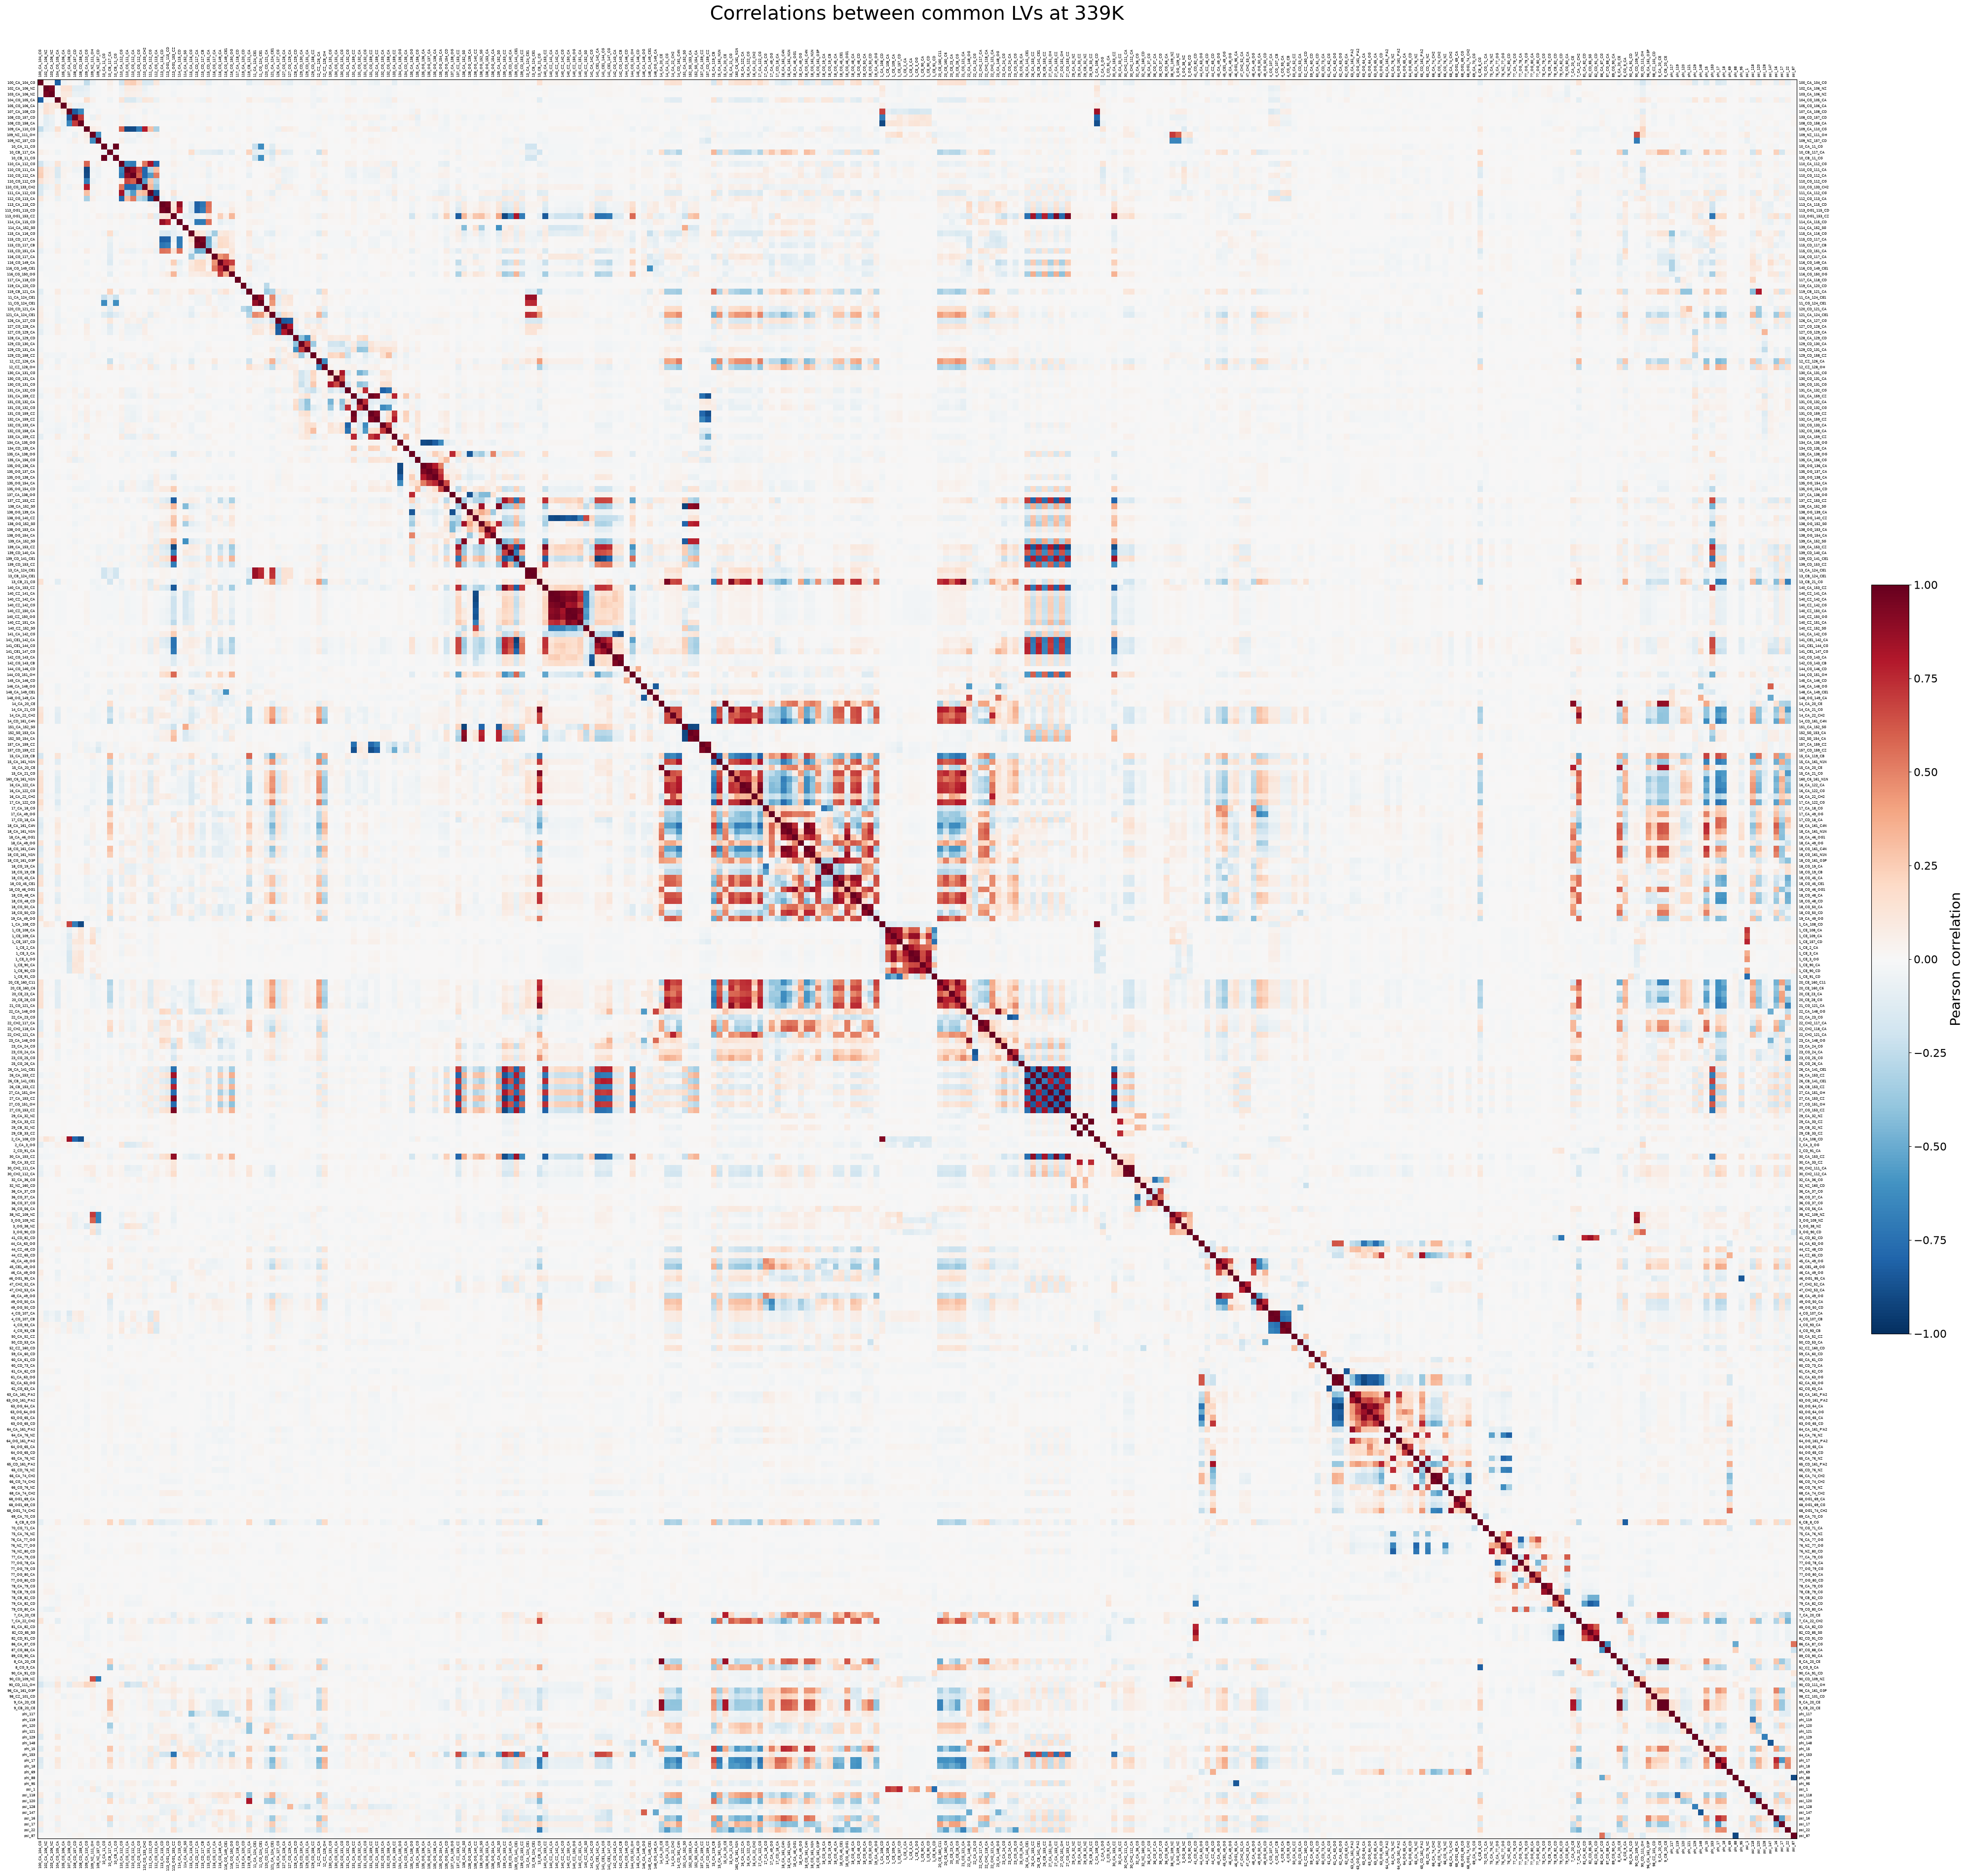

In [20]:
import matplotlib.pyplot as plt

n_LVs = len(LV_names)
for T in temperatures:
    fig, ax = plt.subplots(figsize=(40, 38))   # ~0.1 inch per LV so every label fits

    # Diverging colormap centred on 0: red = positive, blue = negative correlation
    im = ax.imshow(corr[T], cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')

    ax.set_xticks(range(n_LVs))
    ax.set_yticks(range(n_LVs))
    ax.set_xticklabels(LV_names, rotation=90, fontsize=5)
    ax.set_yticklabels(LV_names, fontsize=5)
    ax.tick_params(length=0)
    # Repeat the labels on the top and right edges so they are close to any cell
    ax.tick_params(top=True, labeltop=True, right=True, labelright=True)
    plt.setp(ax.get_xticklabels(), rotation=90)

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Pearson correlation', fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    ax.set_title(f'Correlations between common LVs at {T}', fontsize=28, pad=40)

    fig.tight_layout()
    # The inline figure is downscaled; open the PDF and zoom in to read the labels
    #fig.savefig(f'Analysis300K_339K/correlations_{T}.pdf')
    plt.show()

Variance ratio 339K/300K: median = 1.065 (expected 1.130)
Correlation between covariances (300K vs 339K): 0.830
Best-fit slope: 0.877 (expected 1.130)
RMSE without rescaling: 0.0971
RMSE with Sigma -> (T_339/T_300) Sigma: 0.1034


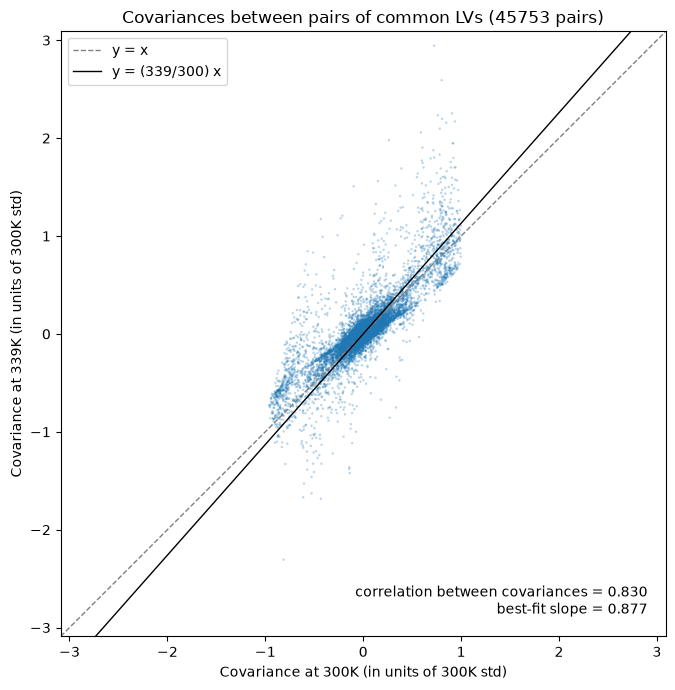

In [21]:
import matplotlib.pyplot as plt

T_300, T_339 = 300., 339.

# Distances (Å) and angles (degrees) have different units, so express both covariance
# matrices in units of the 300K standard deviations: at 300K this is the correlation matrix,
# and the factor T is kept, so Sigma -> T Sigma predicts cov_339K_norm = (T_339 / T_300) * cov_300K_norm
std_300K = np.sqrt(np.diag(cov_300K))
cov_300K_norm = cov_300K / np.outer(std_300K, std_300K)
cov_339K_norm = cov_339K / np.outer(std_300K, std_300K)

# Each pair of LVs appears once: take the upper triangle, without the diagonal (the variances)
i_upper = np.triu_indices(len(LV_names), k=1)
cov_pairs_300K = cov_300K_norm[i_upper]
cov_pairs_339K = cov_339K_norm[i_upper]

# Diagonal: Sigma -> T Sigma predicts that every variance ratio equals T_339 / T_300
var_ratio = np.diag(cov_339K) / np.diag(cov_300K)
print(f'Variance ratio 339K/300K: median = {np.median(var_ratio):.3f} (expected {T_339 / T_300:.3f})')

# Off-diagonal: compare the rescaled baseline with no rescaling (the Pearson r is the same for both)
cov_of_cov = np.corrcoef(cov_pairs_300K, cov_pairs_339K)[0, 1]
slope = (cov_pairs_300K @ cov_pairs_339K) / (cov_pairs_300K @ cov_pairs_300K)   # least-squares fit through 0
rmse = {k: np.sqrt(np.mean((cov_pairs_339K - k * cov_pairs_300K) ** 2)) for k in [1, T_339 / T_300]}
print(f'Correlation between covariances (300K vs 339K): {cov_of_cov:.3f}')
print(f'Best-fit slope: {slope:.3f} (expected {T_339 / T_300:.3f})')
print(f'RMSE without rescaling: {rmse[1]:.4f}')
print(f'RMSE with Sigma -> (T_339/T_300) Sigma: {rmse[T_339 / T_300]:.4f}')

lim = 1.05 * max(np.abs(cov_pairs_300K).max(), np.abs(cov_pairs_339K).max())
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cov_pairs_300K, cov_pairs_339K, s=3, alpha=0.3, edgecolors='none')
ax.plot([-lim, lim], [-lim, lim], color='gray', linewidth=1, linestyle='--', label='y = x')
ax.plot([-lim, lim], [-lim * T_339 / T_300, lim * T_339 / T_300], color='black', linewidth=1, label=f'y = ({T_339:.0f}/{T_300:.0f}) x')

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_xlabel('Covariance at 300K (in units of 300K std)')
ax.set_ylabel('Covariance at 339K (in units of 300K std)')
ax.set_title(f'Covariances between pairs of common LVs ({len(cov_pairs_300K)} pairs)')
ax.text(0.97, 0.03, f'correlation between covariances = {cov_of_cov:.3f}\nbest-fit slope = {slope:.3f}',
        transform=ax.transAxes, ha='right', va='bottom')
ax.legend(loc='upper left')

fig.tight_layout()
plt.show()

So what's cool here is that the relation between correlations at different temperatures is more complex than a simple rescaling. This is the case in the space of $J$ though, so if we could retrieve the proper correlations from the rescaled $J$, that would be awesome. Now we can try to rescale $\Sigma \rightarrow T \Sigma$ and compute the **correlation between correlations** as a baseline to beat by passing through $J$.

In [ ]:
S_300_res = np.load('results/Sigma_300K_res.npy')
# S_300_res is a covariance of the discretized states, so compare it with the covariance
# of the discretized 300K trajectory over the common LVs (not the continuous cov_300K)
S_300_true = np.cov(data_300K_common.T)

In [ ]:
import matplotlib.pyplot as plt

# Off-diagonal: each pair of LVs once (upper triangle); diagonal: the variances
i_upper = np.triu_indices(len(LV_names), k=1)
offdiag_true, offdiag_res = S_300_true[i_upper], S_300_res[i_upper]
diag_true, diag_res = np.diag(S_300_true), np.diag(S_300_res)

r_offdiag = np.corrcoef(offdiag_true, offdiag_res)[0, 1]
rmse_offdiag = np.sqrt(np.mean((offdiag_res - offdiag_true) ** 2))
print(f'Off-diagonal: Pearson r = {r_offdiag:.3f}, RMSE = {rmse_offdiag:.4f}')
print(f'Diagonal: Pearson r = {np.corrcoef(diag_true, diag_res)[0, 1]:.3f}, '
      f'RMSE = {np.sqrt(np.mean((diag_res - diag_true) ** 2)):.4f}')

lo = min(S_300_true.min(), S_300_res.min())
hi = max(S_300_true.max(), S_300_res.max())
pad = 0.05 * (hi - lo)
lo, hi = lo - pad, hi + pad

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(offdiag_true, offdiag_res, s=3, alpha=0.3, edgecolors='none', label='covariances (off-diagonal)')
ax.scatter(diag_true, diag_res, s=12, alpha=0.8, color='tab:orange', edgecolors='none', label='variances (diagonal)')
ax.plot([lo, hi], [lo, hi], color='gray', linewidth=1, linestyle='--', label='y = x')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel(r'$\Sigma_{300K}$ true')
ax.set_ylabel(r'$\Sigma_{300K}$ reconstructed')
ax.set_title(f'Reconstructed vs true covariances at 300K ({len(LV_names)} LVs)')
ax.text(0.97, 0.03, f'off-diagonal: r = {r_offdiag:.3f}, RMSE = {rmse_offdiag:.4f}',
        transform=ax.transAxes, ha='right', va='bottom')
ax.legend(loc='upper left')

fig.tight_layout()
plt.show()